In [1]:
!pip install scikit-image
!pip install skimage

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import time

# Otomatis download data dari Kaggle ke Google Colab
import kagglehub
os.environ['KAGGLE_USERNAME'] = 'muhammadyogaisnaeni'
os.environ['KAGGLE_KEY'] = 'bf6873ff2e9847adefe62b75047f2eb0'

path = kagglehub.competition_download('digit-recognizer')
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

X = train_df.drop('label', axis=1)
y = train_df['label']

# 🚨 SPLIT DATA KONSISTEN (Random Seed = 42) 🚨
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


100%|██████████| 15.3M/15.3M [00:00<00:00, 39.2MB/s]

Extracting files...


Train shape: (42000, 785)
Test shape: (28000, 784)


In [3]:
import pandas as pd

# Read the data
train_file = os.path.join(path, 'train.csv')
test_file = os.path.join(path, 'test.csv')

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

# Display first few rows
train_df.head()
test_df.head()


Train data shape: (42000, 785)
Test data shape: (28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


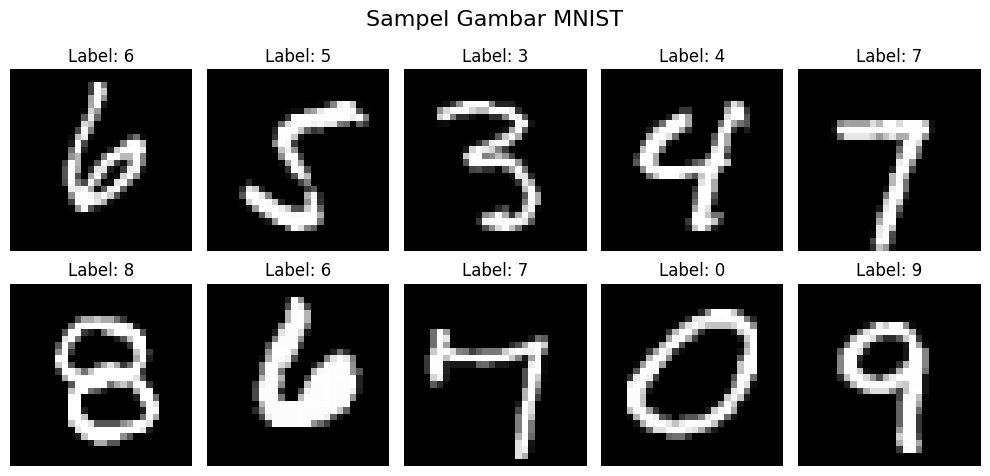

/tmp/ipykernel_7167/1888069712.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis', legend=False)


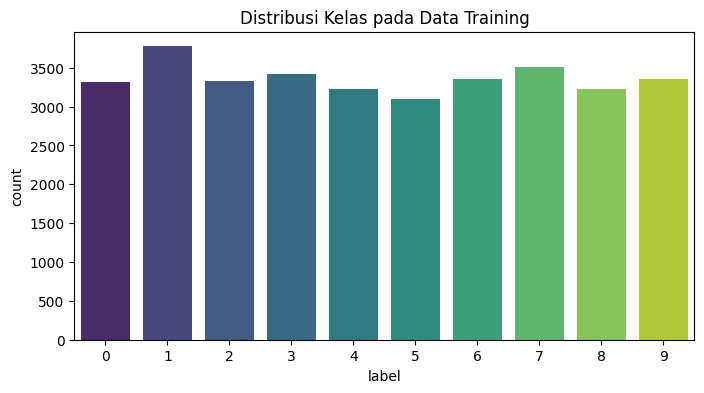

In [4]:
# 1. Visualisasi Sampel Gambar
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = X_train_raw.iloc[i].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_train.iloc[i]}")
    plt.axis('off')
plt.suptitle("Sampel Gambar MNIST", fontsize=16)
plt.tight_layout()
plt.show()

# 2. Distribusi Kelas (Mengecek Balance Data)
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train, palette='viridis', legend=False)
plt.title('Distribusi Kelas pada Data Training')
plt.show()


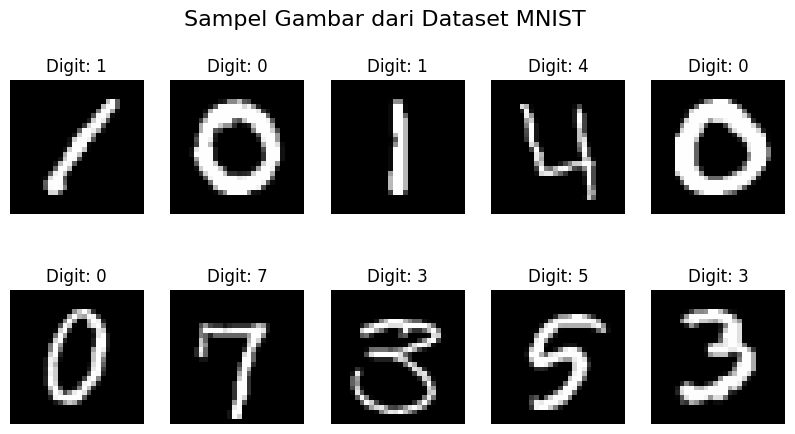

/tmp/ipykernel_7167/733946542.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='viridis')


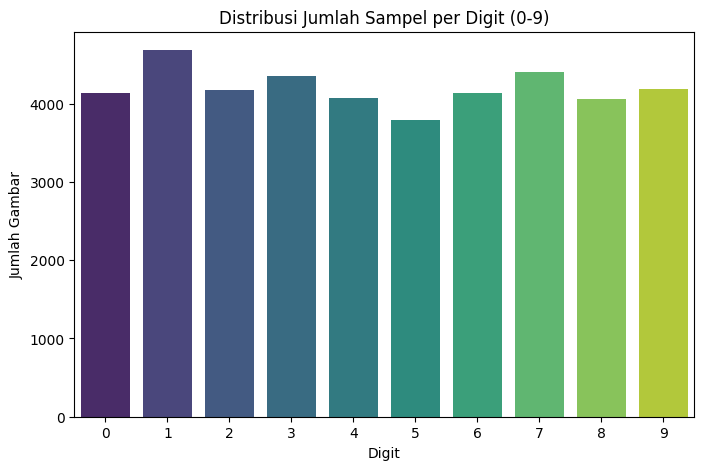

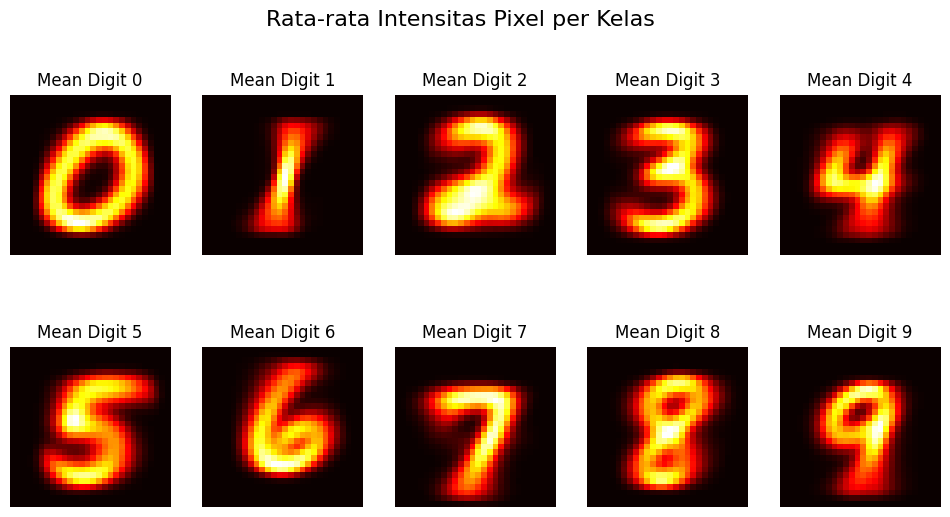

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualisasi Sampel Gambar (Wajib untuk Data Image)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Ambil baris ke-i, drop kolom 'label', lalu reshape ke 28x28
    img = train_df.iloc[i, 1:].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Digit: {train_df.iloc[i, 0]}")
    plt.axis('off')
plt.suptitle("Sampel Gambar dari Dataset MNIST", fontsize=16)
plt.show()

# 2. Distribusi Kelas (Mengecek Balance/Imbalance Data)
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train_df, palette='viridis')
plt.title('Distribusi Jumlah Sampel per Digit (0-9)')
plt.xlabel('Digit')
plt.ylabel('Jumlah Gambar')
plt.show()

# 3. Analisis Intensitas Pixel Rata-rata
# Membantu memahami area mana yang paling sering diarsir
mean_images = train_df.groupby('label').mean().values.reshape(10, 28, 28)
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(mean_images[i], cmap='hot')
    plt.title(f"Mean Digit {i}")
    plt.axis('off')
plt.suptitle("Rata-rata Intensitas Pixel per Kelas", fontsize=16)
plt.show()

In [6]:
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# --- 1. FUNGSI EKSTRAKSI FITUR HOG ---
def extract_hog_features(df):
    hog_features = []
    # Loop melalui setiap baris gambar
    for i in range(len(df)):
        # Reshape data tabular kembali ke 28x28
        img = df.iloc[i].values.reshape(28, 28)

        # Hitung HOG
        # pixels_per_cell=(7, 7) membagi gambar 28x28 menjadi 16 cell (4x4)
        fd = hog(img, orientations=9, pixels_per_cell=(7, 7),
                 cells_per_block=(2, 2), visualize=False)
        hog_features.append(fd)

    return np.array(hog_features)

# Pisahkan Label dan Fitur dari Train Data
X_raw = train_df.drop('label', axis=1)
y = train_df['label']

# Split data (Gunakan 20% untuk validasi agar fair dengan Kasus 1)
from sklearn.model_selection import train_test_split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# --- 2. PROSES EKSTRAKSI (Mungkin butuh waktu 1-2 menit) ---
print("Mengekstrak fitur HOG..)")
X_train_hog = extract_hog_features(X_train_raw)
X_val_hog = extract_hog_features(X_val_raw)

# --- 3. TRAINING SVM ---
print("Training SVM dengan Fitur HOG...")
# Gunakan kernel rbf (default) atau linear
svm_hog = SVC(kernel='rbf', C=10, random_state=42)
svm_hog.fit(X_train_hog, y_train)

# --- 4. EVALUASI ---
y_pred_svm = svm_hog.predict(X_val_hog)
acc_svm = accuracy_score(y_val, y_pred_svm)

print(f"\n--- HOG + SVM Performance ---")
print(f"Accuracy: {acc_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_svm))

Mengekstrak fitur HOG..)
Training SVM dengan Fitur HOG...

--- HOG + SVM Performance ---
Accuracy: 0.9837

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       816
           1       0.99      0.99      0.99       909
           2       0.98      0.98      0.98       846
           3       0.98      0.97      0.98       937
           4       0.99      0.98      0.99       839
           5       0.99      0.98      0.98       702
           6       0.99      0.99      0.99       785
           7       0.98      0.98      0.98       893
           8       0.97      0.98      0.98       835
           9       0.97      0.98      0.98       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. PREPROCESSING DATA UNTUK CNN ---

X_train_cnn = X_train_raw.values.reshape(-1, 28, 28, 1) / 255.0
X_val_cnn = X_val_raw.values.reshape(-1, 28, 28, 1) / 255.0

# --- 2. MEMBANGUN ARSITEKTUR DEEP CNN (OPSI BONUS) ---
def build_deep_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2 (Lebih Dalam)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully Connected Layer
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax') # 10 kelas (0-9)
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 3. TRAINING ---
deep_cnn = build_deep_cnn()
print("Training Deep CNN")

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = deep_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop],
    verbose=1
)

# --- 4. EVALUASI ---
val_loss, val_acc = deep_cnn.evaluate(X_val_cnn, y_val, verbose=0)
print(f"\n--- Deep CNN Performance ---")
print(f"Validation Accuracy: {val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deep CNN
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 112s 208ms/step - accuracy: 0.9266 - loss: 0.2398 - val_accuracy: 0.9543 - val_loss: 0.1664
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 109s 208ms/step - accuracy: 0.9760 - loss: 0.0805 - val_accuracy: 0.9887 - val_loss: 0.0379
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 110s 210ms/step - accuracy: 0.9826 - loss: 0.0581 - val_accuracy: 0.9887 - val_loss: 0.0352
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 113s 214ms/step - accuracy: 0.9833 - loss: 0.0518 - val_accuracy: 0.9881 - val_loss: 0.0337
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 117s 222ms/step - accuracy: 0.9871 - loss: 0.0438 - val_accuracy: 0.9904 - val_loss: 0.0313
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 132s 204ms/step - accuracy: 0.9883 - loss: 0.0399 - val_accuracy: 0.9921 - val_loss: 0.0248
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 112s 213ms/step - accuracy: 0.9887 - loss: 0.0382 - val_accuracy: 0.9919 - val_loss: 0.0244
Epoch 8/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 138s 206ms/step - 

263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


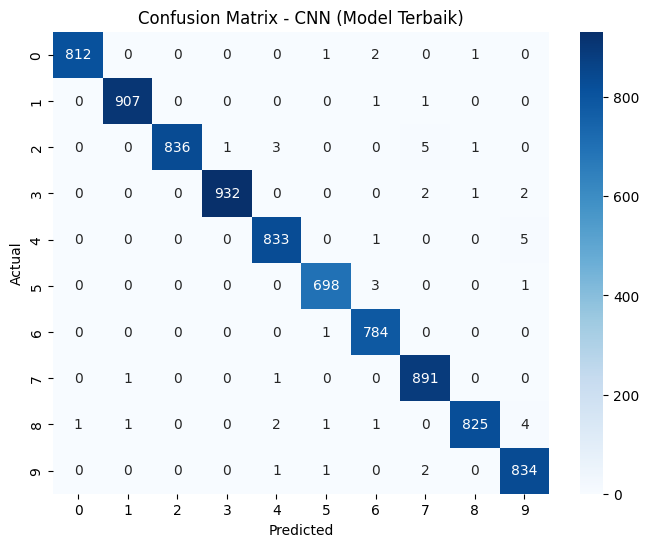

Jumlah prediksi salah (CNN): 48 dari 8400


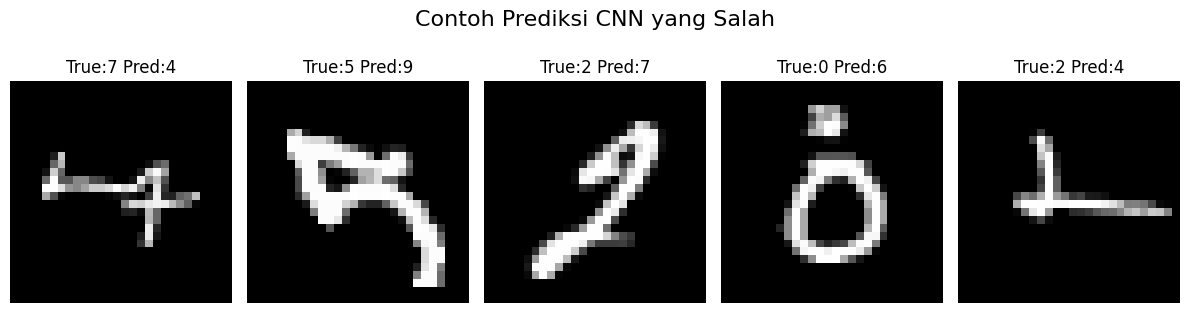

--- ANALISIS OBJEKTIF & TRADE-OFF ---
SVM Akurasi: 0.9837 | Waktu Inferensi: 0.0001 detik
CNN Akurasi: 0.9943 | Waktu Inferensi: 7.0225 detik

Kesimpulan:
1. Keduanya memiliki akurasi yang luar biasa (>98%), namun CNN sedikit lebih superior.
2. Dari segi waktu inferensi, CNN jauh lebih cepat dibanding SVM karena proses klasifikasi
   matriks CNN sangat teroptimasi di CPU/GPU, sedangkan SVM konvensional membutuhkan 
   komputasi jarak (kernel) ke ribuan data support vector yang berat saat testing.


In [9]:
import time

# Assign deep_cnn to cnn_model for consistency
cnn_model = deep_cnn

# Make predictions for CNN and SVM
start_time_cnn = time.time()
cnn_preds = np.argmax(cnn_model.predict(X_val_cnn), axis=1)
cnn_inference_time = time.time() - start_time_cnn

start_time_svm = time.time()
svm_preds = y_pred_svm # y_pred_svm is already calculated in the HOG+SVM cell
svm_inference_time = time.time() - start_time_svm

# 1. Confusion Matrix CNN
cm = confusion_matrix(y_val, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN (Model Terbaik)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 2. Error Analysis (Menampilkan gambar yang salah diprediksi oleh CNN)
errors_idx = np.where(y_val.values != cnn_preds)[0]
print(f"Jumlah prediksi salah (CNN): {len(errors_idx)} dari {len(y_val)}")

plt.figure(figsize=(12, 3))
for i, idx in enumerate(errors_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_val_cnn[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True:{y_val.values[idx]} Pred:{cnn_preds[idx]}")
    plt.axis('off')
plt.suptitle("Contoh Prediksi CNN yang Salah", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# 3. Analisis Objektif (Perbandingan Akurasi vs Waktu)
print("--- ANALISIS OBJEKTIF & TRADE-OFF ---")
print(f"SVM Akurasi: {accuracy_score(y_val, svm_preds):.4f} | Waktu Inferensi: {svm_inference_time:.4f} detik")
print(f"CNN Akurasi: {accuracy_score(y_val, cnn_preds):.4f} | Waktu Inferensi: {cnn_inference_time:.4f} detik")
print("\nKesimpulan:")
print("1. Keduanya memiliki akurasi yang luar biasa (>98%), namun CNN sedikit lebih superior.")
print("2. Dari segi waktu inferensi, CNN jauh lebih cepat dibanding SVM karena proses klasifikasi")
print("   matriks CNN sangat teroptimasi di CPU/GPU, sedangkan SVM konvensional membutuhkan ")
print("   komputasi jarak (kernel) ke ribuan data support vector yang berat saat testing.")

In [10]:
# Preprocessing data test untuk CNN
X_test_cnn = test_df.values.reshape(-1, 28, 28, 1) / 255.0

# Prediksi menggunakan CNN (model terbaik kita), using 'deep_cnn' as the model
print("Membuat prediksi untuk file submission Kaggle...")
final_preds_prob = deep_cnn.predict(X_test_cnn)
final_preds = np.argmax(final_preds_prob, axis=1)

# Buat DataFrame
submission = pd.DataFrame({
    'ImageId': range(1, len(final_preds) + 1),
    'Label': final_preds
})

submission.to_csv('submission_kasus2.csv', index=False)
print("Selesai! File 'submission_kasus2.csv' berhasil dibuat.")

Membuat prediksi untuk file submission Kaggle...
875/875 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step
Selesai! File 'submission_kasus2.csv' berhasil dibuat.
